<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 115.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 83.7 MB/s eta 0:00:00


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv('Norm Age - Comp Outliers.csv')

# Display the first few rows to understand the structure of the dataset
df.head()

,Unnamed: 0.1,Unnamed: 0,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,...,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,Continent
0,0,0,2,I am a developer by profession,39.5,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,8.0,Europe
1,1,1,3,I am a developer by profession,49.5,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",...,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,8.0,Europe
2,2,2,7,"I am not primarily a developer, but I write co...",39.5,"Employed, full-time",Remote,Apples,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",...,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,8.0,North America
3,3,3,9,I code primarily as a hobby,49.5,"Employed, full-time",In-person,Apples,Hobby,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",...,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,8.0,Europe
4,4,4,10,I am a developer by profession,39.5,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",...,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,8.0,Europe


In [3]:
df = df.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis=1)

<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


In [4]:
%matplotlib inline
plt.rcParams["figure.figsize"] = (15, 6)

Text(0.5, 0.98, 'Compensation Distribution')

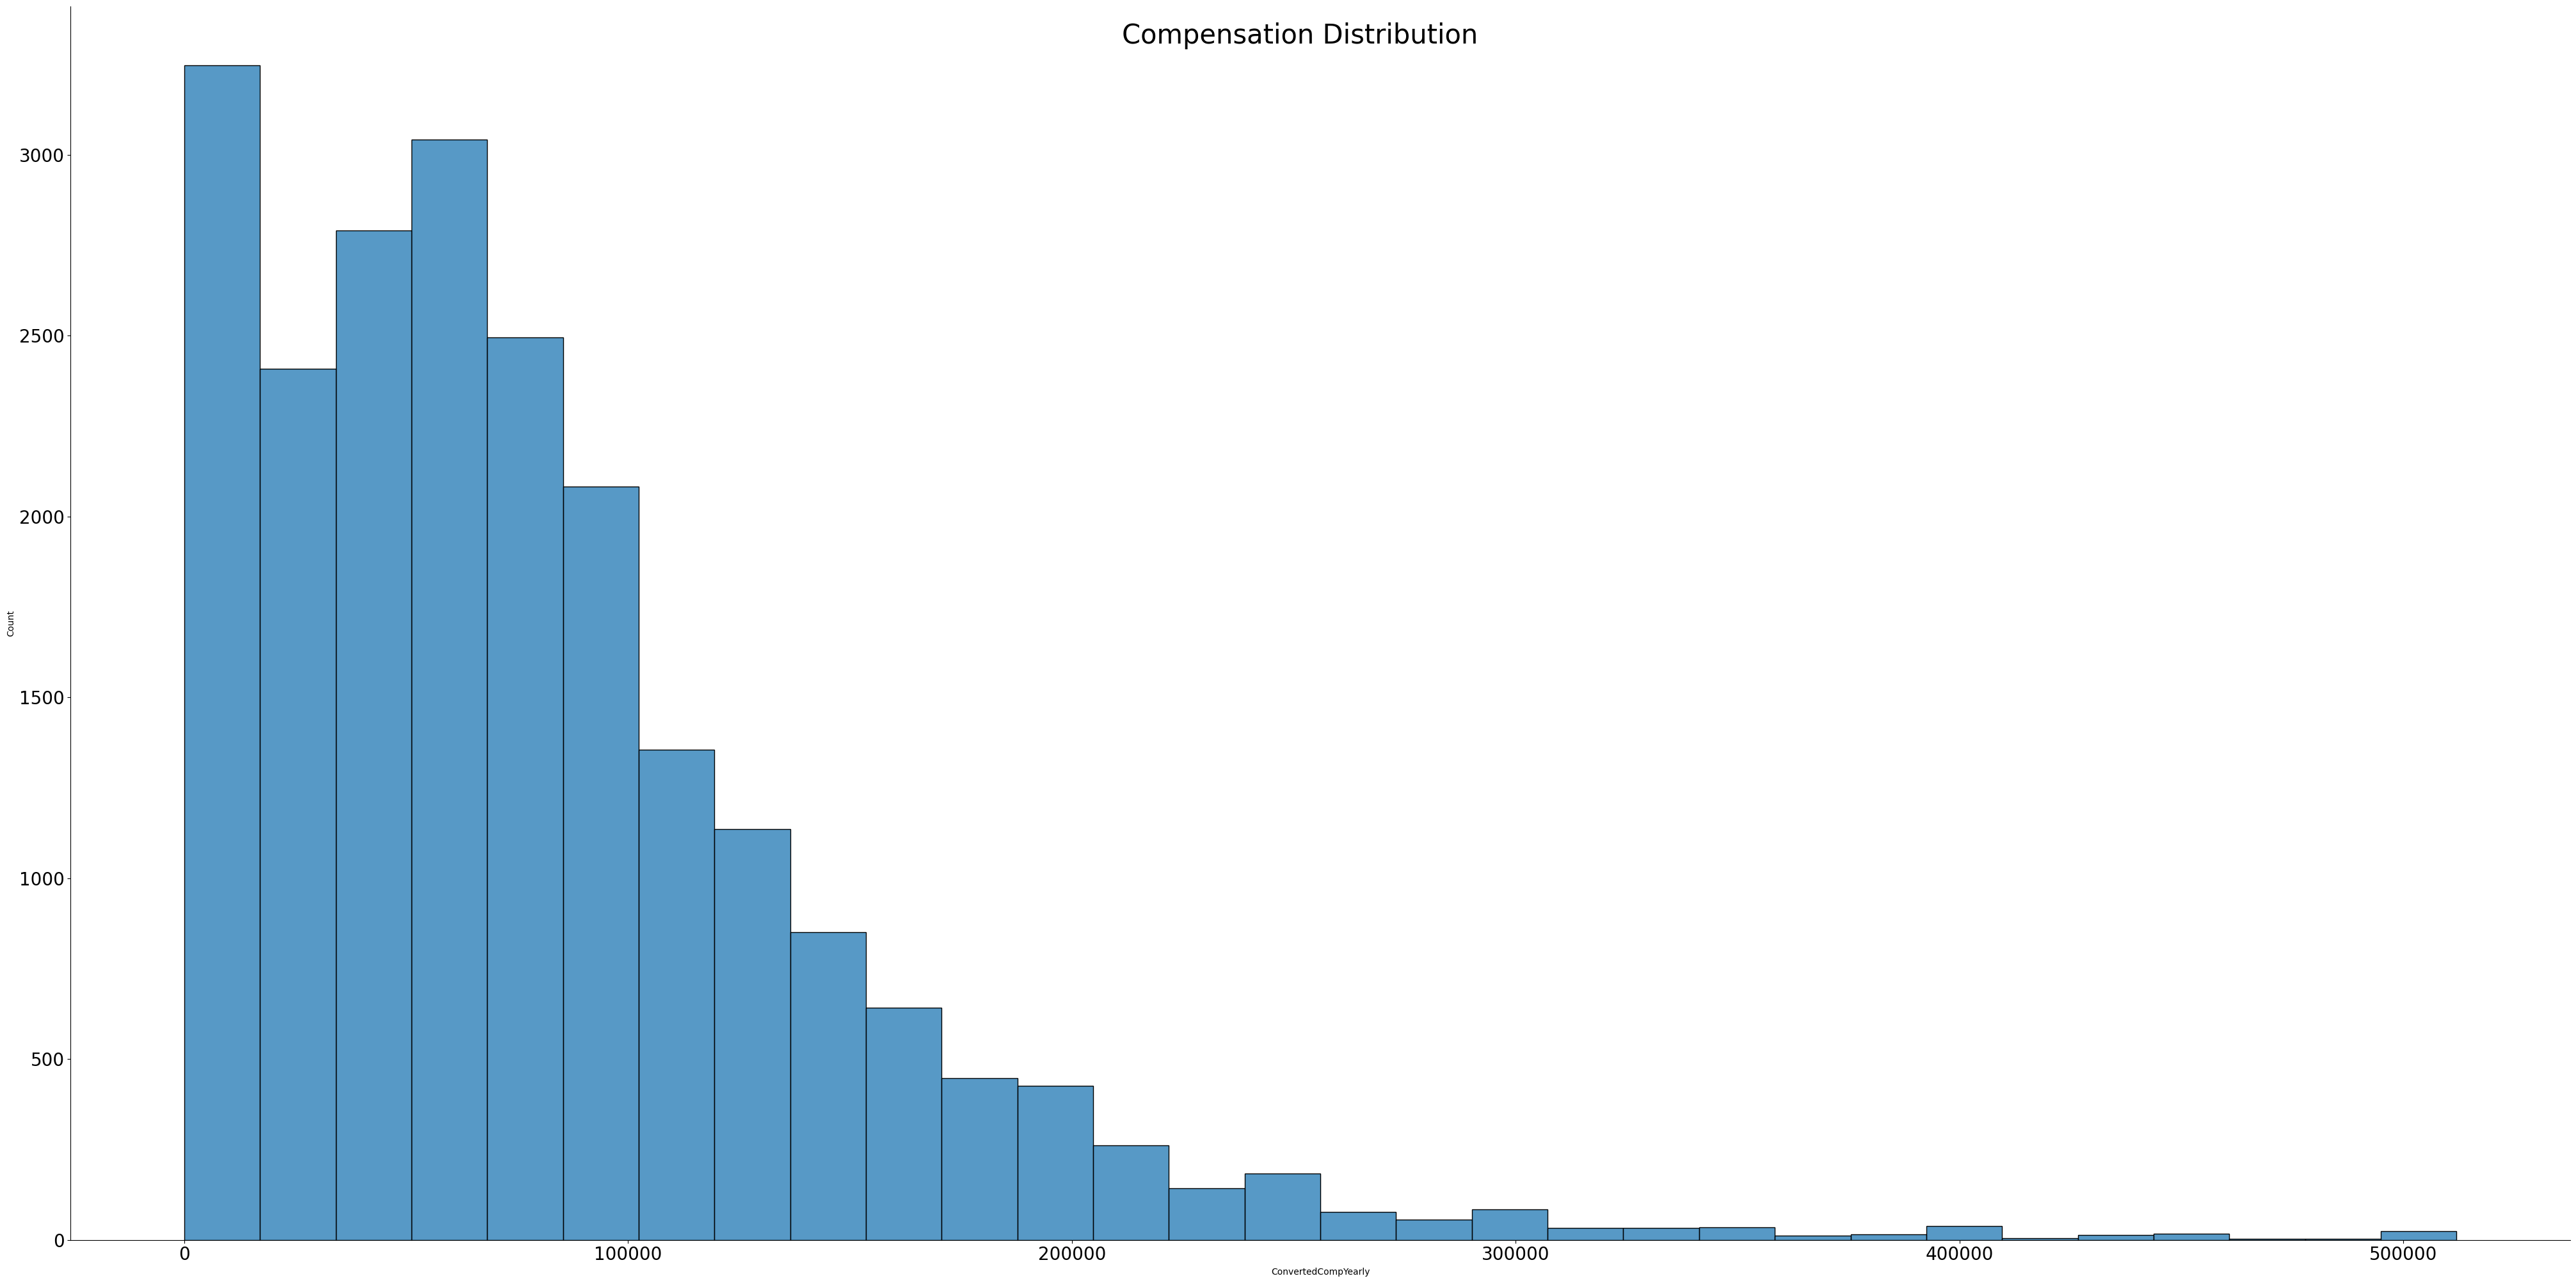

In [5]:
## Write your code here
g=sns.displot(df['ConvertedCompYearly'], bins = 30, height = 20, aspect = 2)
g.tick_params(axis='x', labelsize=20)
g.tick_params(axis='y', labelsize=20)
g.fig.suptitle('Compensation Distribution', fontsize=30)

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [6]:
## Write your code here
#median = df['ConvertedCompYearly'].median()
#df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(median)

In [7]:
a = df[['Employment', 'ConvertedCompYearly']].copy()
a['Employment'] = a['Employment'].str.split(';')
ex = a.explode('Employment')

In [8]:
ex.groupby(['Employment']).median()

,ConvertedCompYearly
Employment,
"Employed, full-time",66878.0
"Employed, part-time",28800.0
"Independent contractor, freelancer, or self-employed",64444.0
"Not employed, and not looking for work",51931.0
"Not employed, but looking for work",23385.5
Retired,64444.0
"Student, full-time",19712.0
"Student, part-time",28806.0


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.

Изучите диапазон компенсаций в столбце ConvertedCompYearly, анализируя различия между странами. Используйте боксплоты для сравнения распределений компенсаций для каждой страны, чтобы выявить вариации и аномалии в каждом регионе, предоставляя информацию о глобальных тенденциях компенсаций.

In [9]:
#pd.set_option('display.max_columns', None)      # показать все колонки
#pd.set_option('display.max_rows', None)         # показать все строки
#pd.set_option('display.max_colwidth', None)     # показать весь текст в ячейках
#pd.set_option('display.expand_frame_repr', False)

<Axes: xlabel='Continent', ylabel='ConvertedCompYearly'>

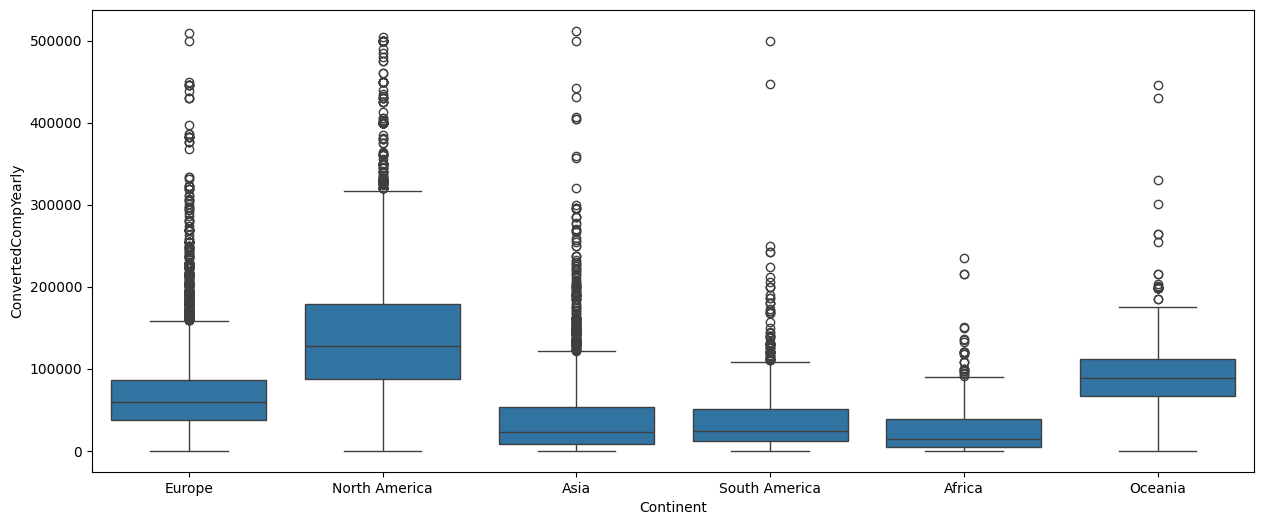

In [10]:
## Write your code here
sns.boxplot(df, x='Continent', y='ConvertedCompYearly')

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [11]:
## Write your code here
def find_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]
out_by_cont = df.groupby('Continent')['ConvertedCompYearly'].apply(find_outliers)

In [12]:
out_by_cont.shape

(926,)

In [13]:
out_idx = out_by_cont.index.get_level_values(1)
df_new=df.drop(out_idx)

<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


In [14]:
## Write your code here
df_cor = df_new[['WorkExp', 'JobSatPoints_1', 'ConvertedCompYearly']]

In [15]:
df_cor=df_cor.corr()

<Axes: >

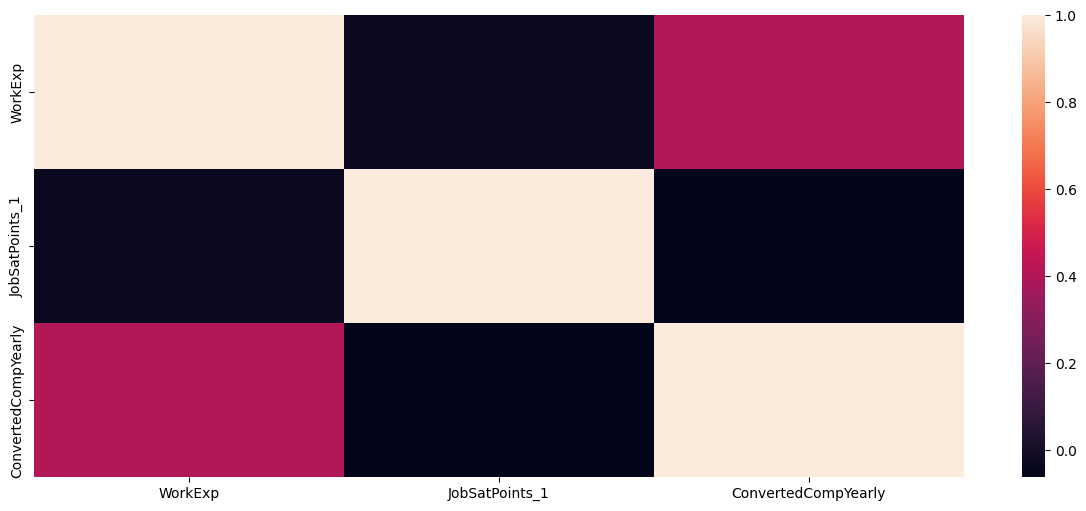

In [16]:

sns.heatmap(df_cor)

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.

Создайте диаграммы рассеяния, чтобы изучить конкретные корреляции между ConvertedCompYearly и WorkExp, а также между ConvertedCompYearly и JobSatPoints_1.

In [17]:
!pip install numpy
import numpy as np

In [18]:
df_new['ConvertedCompYearly_log'] = np.log10(df_new['ConvertedCompYearly'])
df_new['WorkExp_log'] = np.log1p(df_new['WorkExp'])

<Axes: xlabel='WorkExp_log', ylabel='ConvertedCompYearly_log'>

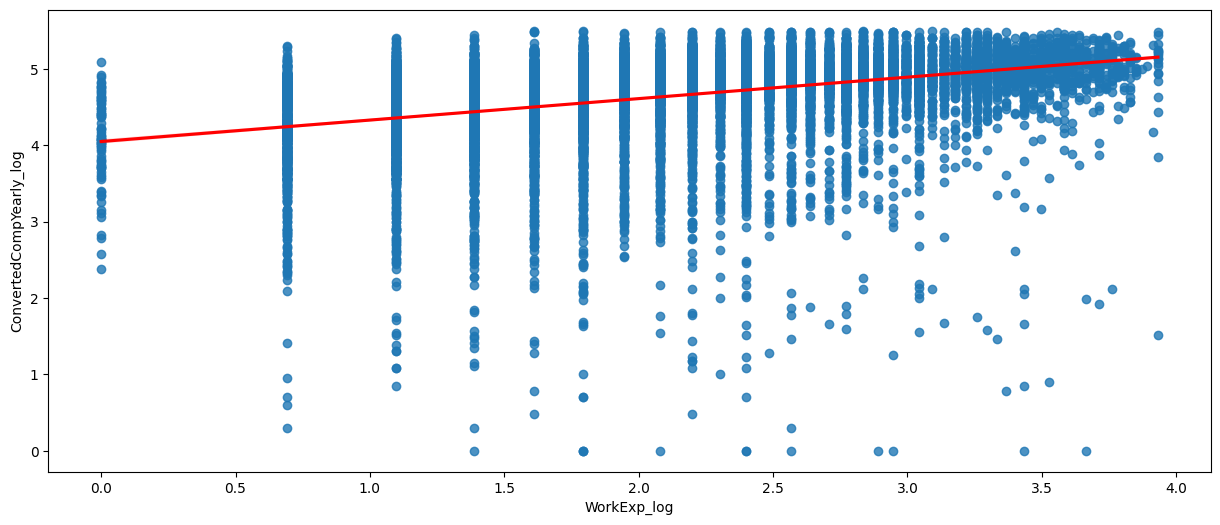

In [20]:
## Write your code here
sns.regplot(df_new, x='WorkExp_log', y='ConvertedCompYearly_log', line_kws={'color':'red'})

<Axes: xlabel='JobSatPoints_1_log', ylabel='ConvertedCompYearly_log'>

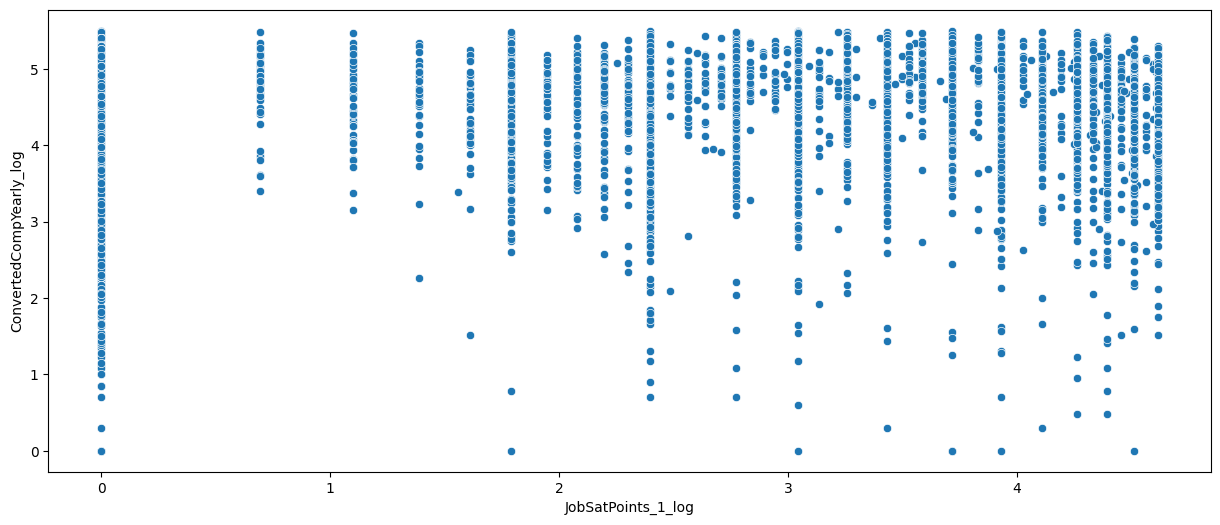

In [21]:
df_new['JobSatPoints_1_log']=np.log1p(df_new['JobSatPoints_1'])
sns.scatterplot(df_new,x='JobSatPoints_1_log', y='ConvertedCompYearly_log')

In [22]:
df_new['ConvertedCompYearly'].mean()

np.float64(72470.42465427933)

<Axes: xlabel='Age', ylabel='WorkExp'>

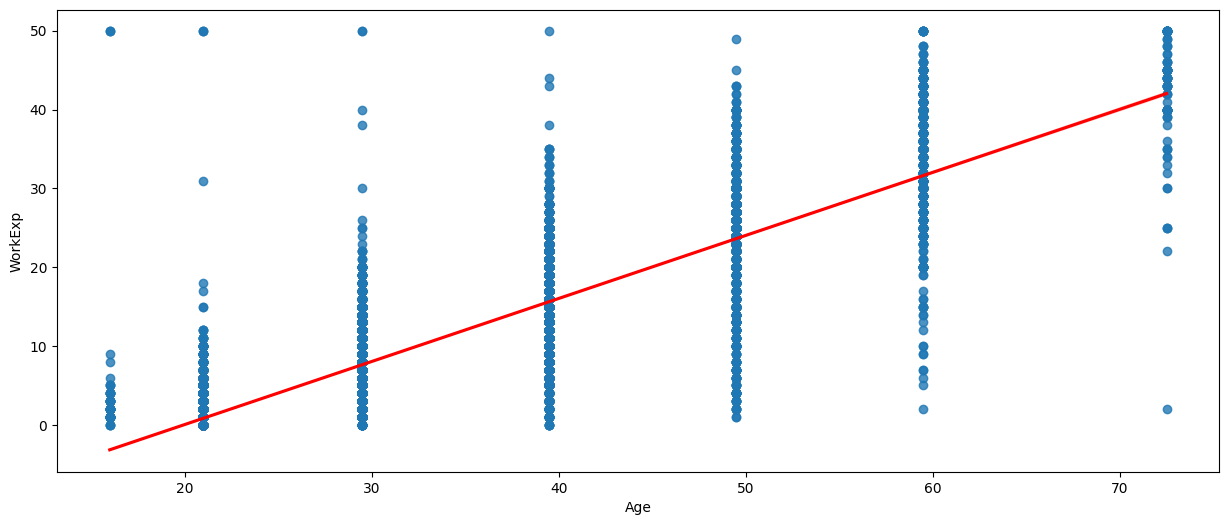

In [25]:
sns.regplot(df_new, x='Age', y='WorkExp', line_kws={'color':'red'})

In [24]:
df_new.to_csv('Lab13 Log Comp - Out.csv')

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
